# 💳 신용카드 이상거래 탐지

**목표:** 신용카드 거래 데이터에서 사기 거래를 정확히 탐지한다.

**핵심 문제:** 전체 거래의 0.17%만 사기 → 극심한 불균형 데이터  
→ 단순히 '전부 정상'으로 예측해도 정확도 99.8% → 의미없는 모델  
→ Precision, Recall, F1-Score, AUC-ROC로 평가해야 한다.

**사용 모델:**
- 기초: 로지스틱 회귀, 결정 트리, KNN, 나이브 베이즈, SVM
- 앙상블: 랜덤 포레스트, XGBoost, LightGBM
- 딥러닝: 신경망(MLP)

In [1]:
# ─────────────────────────────────────────
# 1단계: 라이브러리 로드
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 기초 모델
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# 앙상블 모델
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# 딥러닝(신경망)
from sklearn.neural_network import MLPClassifier

# 평가 지표
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# 불균형 데이터 처리
from imblearn.over_sampling import SMOTE

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
print('라이브러리 로드 완료!')

라이브러리 로드 완료!


In [2]:
# ─────────────────────────────────────────
# 2단계: 데이터 로드 및 기본 탐색
# ─────────────────────────────────────────
# V1~V28: PCA로 변환된 특성 (개인정보 보호를 위해 원본 이름 숨김)
# Amount: 거래 금액, Time: 첫 거래로부터 경과 시간(초), Class: 0=정상, 1=사기

df = pd.read_csv('../data/creditcard.csv')

print(f'데이터 크기: {df.shape[0]:,}행 x {df.shape[1]}열')
print(f'\n=== 클래스 분포 (불균형 확인) ===')
print(df['Class'].value_counts())
print(f'\n사기 거래 비율: {df["Class"].mean()*100:.3f}%')
df.head()

데이터 크기: 284,807행 x 31열

=== 클래스 분포 (불균형 확인) ===
Class
0    284315
1       492
Name: count, dtype: int64

사기 거래 비율: 0.173%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


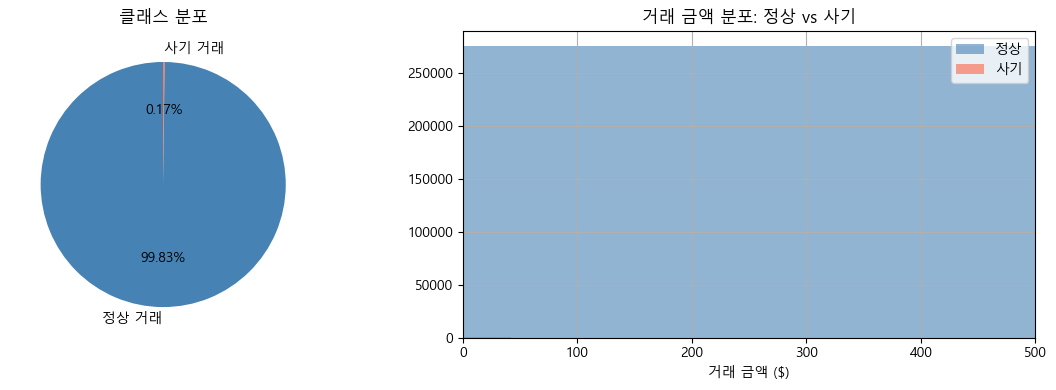

In [3]:
# 클래스 불균형 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Class'].value_counts()
axes[0].pie(counts, labels=['정상 거래', '사기 거래'], autopct='%1.2f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[0].set_title('클래스 분포')

df[df['Class']==0]['Amount'].hist(ax=axes[1], bins=50, alpha=0.6, color='steelblue', label='정상')
df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50, alpha=0.6, color='tomato', label='사기')
axes[1].set_title('거래 금액 분포: 정상 vs 사기')
axes[1].set_xlabel('거래 금액 ($)')
axes[1].legend()
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

In [4]:
# ─────────────────────────────────────────
# 3단계: 데이터 전처리
# ─────────────────────────────────────────

# Amount와 Time은 스케일이 다르므로 정규화 (V1~V28은 이미 PCA로 정규화됨)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

features = [col for col in df.columns if col not in ['Class', 'Amount', 'Time']]
X = df[features]
y = df['Class']

# stratify: 훈련/테스트에서 사기 비율 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=111, stratify=y
)

print(f'훈련 데이터: {len(X_train):,}개')
print(f'테스트 데이터: {len(X_test):,}개')
print(f'\n훈련 데이터 내 사기 거래: {y_train.sum()}개 ({y_train.mean()*100:.2f}%)')

훈련 데이터: 227,845개
테스트 데이터: 56,962개

훈련 데이터 내 사기 거래: 394개 (0.17%)


In [5]:
# ─────────────────────────────────────────
# 4단계: SMOTE로 불균형 해소
# ─────────────────────────────────────────
# 소수 클래스(사기) 데이터를 인위적으로 생성해서 균형을 맞춤
# ※ 테스트 데이터에는 절대 적용하면 안 됨 (현실 데이터 오염 방지)

smote = SMOTE(random_state=111)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('=== SMOTE 적용 전후 비교 ===')
print(f'적용 전 - 정상: {(y_train==0).sum():,}개, 사기: {(y_train==1).sum():,}개')
print(f'적용 후 - 정상: {(y_train_bal==0).sum():,}개, 사기: {(y_train_bal==1).sum():,}개')

=== SMOTE 적용 전후 비교 ===
적용 전 - 정상: 227,451개, 사기: 394개
적용 후 - 정상: 227,451개, 사기: 227,451개


In [6]:
# ─────────────────────────────────────────
# 5단계: 모델 정의
# ─────────────────────────────────────────

models = {
    # 기초 모델
    '로지스틱 회귀': LogisticRegression(random_state=111, max_iter=1000),
    '결정 트리': DecisionTreeClassifier(
        random_state=111, max_depth=10,
        class_weight='balanced'  # 사기 데이터 가중치 자동 부여
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    '나이브 베이즈': GaussianNB(),
    'SVM': SVC(
        kernel='rbf',            # RBF 커널: 비선형 경계도 처리 가능
        class_weight='balanced', # 사기 데이터 가중치 자동 부여
        probability=True,        # predict_proba 사용을 위해 필요
        random_state=111
    ),

    # 앙상블 모델
    '랜덤 포레스트': RandomForestClassifier(n_estimators=100, random_state=111, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, random_state=111,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),  # 불균형 자동 보정
        eval_metric='logloss', verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, random_state=111,
        class_weight='balanced', verbose=-1
    ),

    # 딥러닝 모델
    '신경망(MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32),  # 64개 뉴런 층 → 32개 뉴런 층 2층 구조
        max_iter=50, random_state=111,
        early_stopping=True           # 과적합 방지를 위한 조기 종료
    ),
}

# SVM, KNN, 나이브 베이즈는 SMOTE 데이터(45만 행)가 너무 커서 원본 사용
# SVM은 추가로 1만 건만 샘플링 (SVM은 데이터 수 제곱에 비례해 속도가 급격히 느려짐)
use_original = {'KNN', '나이브 베이즈', 'SVM'}

print('모델 준비 완료! 총', len(models), '개')

모델 준비 완료! 총 9 개


In [7]:
# ─────────────────────────────────────────
# 6단계: 전체 모델 학습 및 성능 평가
# ─────────────────────────────────────────

results = []

for name, model in models.items():
    # 모델별 훈련 데이터 선택
    X_tr = X_train if name in use_original else X_train_bal
    y_tr = y_train if name in use_original else y_train_bal

    # SVM은 전체 데이터에서 학습하면 수십 분이 걸리므로 1만 건만 샘플링
    # (사기 394건 전부 포함 + 정상 9,606건 무작위 선택)
    if name == 'SVM':
        fraud_idx = X_tr[y_tr == 1].index
        normal_idx = X_tr[y_tr == 0].sample(n=9606, random_state=111).index
        sample_idx = fraud_idx.append(normal_idx)
        X_tr = X_tr.loc[sample_idx]
        y_tr = y_tr.loc[sample_idx]
        print(f'[SVM] 샘플 크기: {len(X_tr):,}개 (사기 {y_tr.sum()}개 포함)')

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # 사기일 확률

    auc    = roc_auc_score(y_test, y_prob)
    f1     = f1_score(y_test, y_pred)           # 사기 클래스 기준
    recall = (y_pred[y_test==1] == 1).mean()    # 실제 사기 중 탐지 비율
    prec   = y_pred[y_pred==1].mean() if y_pred.sum() > 0 else 0

    results.append({
        '모델': name,
        'AUC-ROC': round(auc, 4),
        'F1-Score': round(f1, 4),
        'Recall(탐지율)': round(recall, 4),
        'Precision(정밀도)': round(prec, 4),
    })

    print(f'[{name}] AUC={auc:.4f} | F1={f1:.4f} | Recall={recall:.4f} | Precision={prec:.4f}')

print('\n모든 모델 학습 완료!')

[로지스틱 회귀] AUC=0.9874 | F1=0.1173 | Recall=0.9286 | Precision=1.0000
[결정 트리] AUC=0.9216 | F1=0.2042 | Recall=0.8878 | Precision=1.0000
[KNN] AUC=0.9285 | F1=0.8729 | Recall=0.8061 | Precision=1.0000
[나이브 베이즈] AUC=0.9596 | F1=0.1172 | Recall=0.8673 | Precision=1.0000
[SVM] 샘플 크기: 10,000개 (사기 394개 포함)
[SVM] AUC=0.9791 | F1=0.2468 | Recall=0.8776 | Precision=1.0000
[랜덤 포레스트] AUC=0.9686 | F1=0.8852 | Recall=0.8265 | Precision=1.0000
[XGBoost] AUC=0.9641 | F1=0.6693 | Recall=0.8571 | Precision=1.0000
[LightGBM] AUC=0.9850 | F1=0.7478 | Recall=0.8776 | Precision=1.0000
[신경망(MLP)] AUC=0.9627 | F1=0.8040 | Recall=0.8163 | Precision=1.0000

모든 모델 학습 완료!


In [8]:
# ─────────────────────────────────────────
# 7단계: 성능 비교 표
# ─────────────────────────────────────────

results_df = pd.DataFrame(results).set_index('모델')
results_df = results_df.sort_values('F1-Score', ascending=False)
print('=== 모델 성능 비교 (F1-Score 기준 정렬) ===')
results_df

=== 모델 성능 비교 (F1-Score 기준 정렬) ===


,AUC-ROC,F1-Score,Recall(탐지율),Precision(정밀도)
모델,,,,
랜덤 포레스트,0.9686,0.8852,0.8265,1.0
KNN,0.9285,0.8729,0.8061,1.0
신경망(MLP),0.9627,0.8040,0.8163,1.0
LightGBM,0.9850,0.7478,0.8776,1.0
XGBoost,0.9641,0.6693,0.8571,1.0
SVM,0.9791,0.2468,0.8776,1.0
결정 트리,0.9216,0.2042,0.8878,1.0
로지스틱 회귀,0.9874,0.1173,0.9286,1.0
나이브 베이즈,0.9596,0.1172,0.8673,1.0


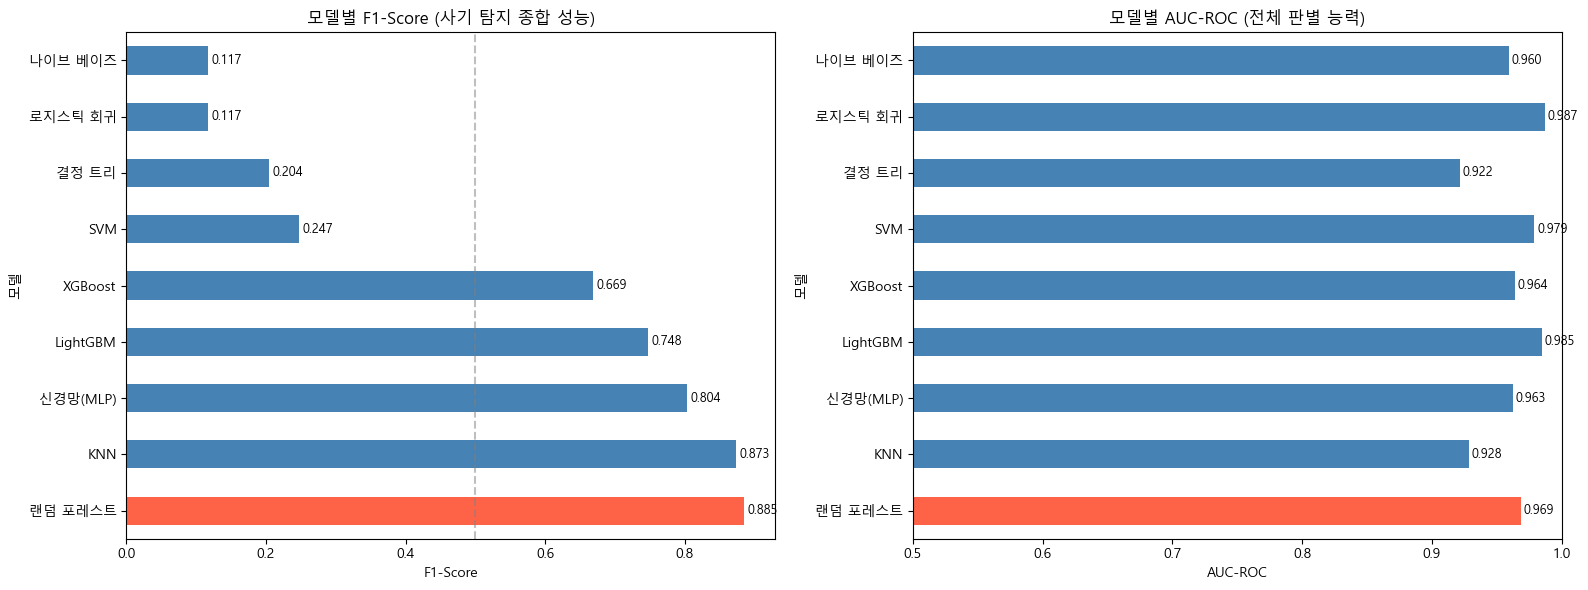

In [9]:
# ─────────────────────────────────────────
# 8단계: 성능 시각화 - 모델 비교 막대그래프
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# 1위 모델은 빨간색으로 강조, 나머지는 파란색
colors = ['tomato' if i == 0 else 'steelblue' for i in range(len(results_df))]

# F1-Score 비교
results_df['F1-Score'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('모델별 F1-Score (사기 탐지 종합 성능)', fontsize=12)
axes[0].set_xlabel('F1-Score')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(results_df['F1-Score']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# AUC-ROC 비교
results_df['AUC-ROC'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('모델별 AUC-ROC (전체 판별 능력)', fontsize=12)
axes[1].set_xlabel('AUC-ROC')
axes[1].set_xlim(0.5, 1.0)
for i, v in enumerate(results_df['AUC-ROC']):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

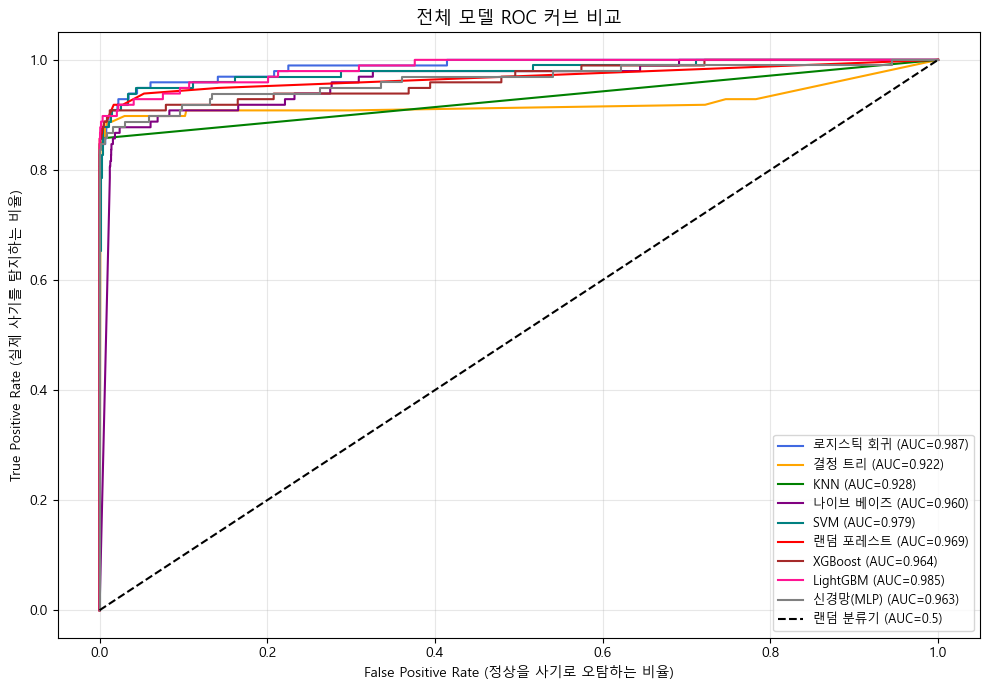

In [10]:
# ─────────────────────────────────────────
# 9단계: ROC 커브 비교 (전체 모델)
# ─────────────────────────────────────────

plt.figure(figsize=(10, 7))

color_map = {
    '로지스틱 회귀': 'royalblue', '결정 트리': 'orange',
    'KNN': 'green', '나이브 베이즈': 'purple', 'SVM': 'teal',
    '랜덤 포레스트': 'red', 'XGBoost': 'brown',
    'LightGBM': 'deeppink', '신경망(MLP)': 'gray',
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color_map[name])

plt.plot([0, 1], [0, 1], 'k--', label='랜덤 분류기 (AUC=0.5)')
plt.title('전체 모델 ROC 커브 비교', fontsize=13)
plt.xlabel('False Positive Rate (정상을 사기로 오탐하는 비율)')
plt.ylabel('True Positive Rate (실제 사기를 탐지하는 비율)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

최고 성능 모델: 랜덤 포레스트


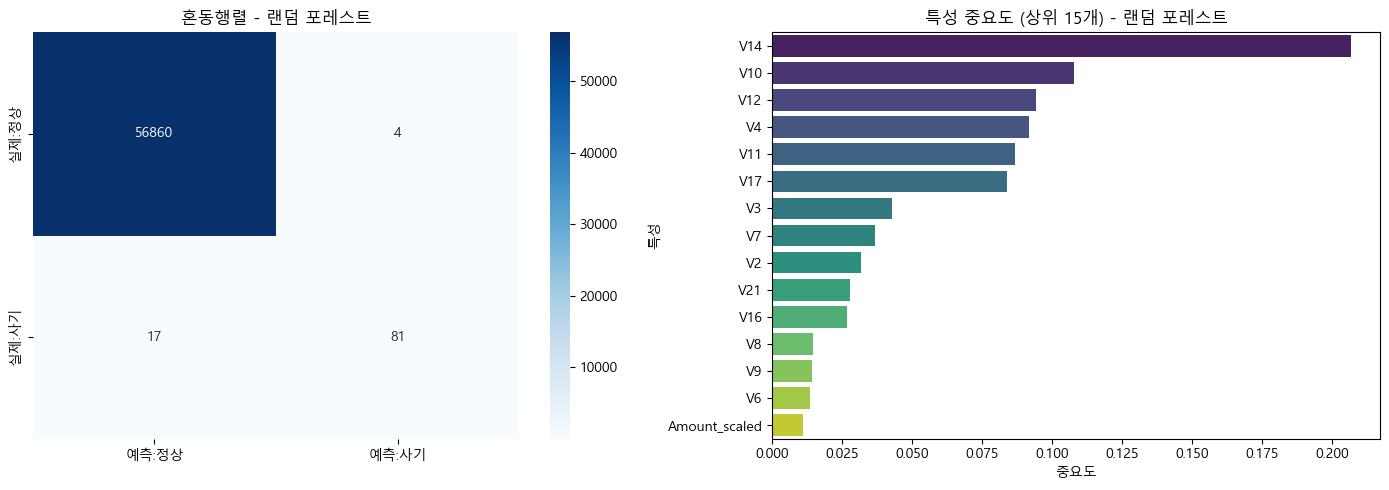

In [11]:
# ─────────────────────────────────────────
# 10단계: 최고 성능 모델 상세 분석
# ─────────────────────────────────────────
# F1-Score 기준 1위 모델의 혼동행렬 + 특성 중요도

best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f'최고 성능 모델: {best_model_name}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 혼동행렬: TP(사기→사기 탐지) | FP(정상→사기 오탐) | FN(사기→정상 놓침) | TN(정상→정상)
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['예측:정상', '예측:사기'],
            yticklabels=['실제:정상', '실제:사기'])
axes[0].set_title(f'혼동행렬 - {best_model_name}')

# 특성 중요도 (트리 계열 모델만 지원)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        '특성': features,
        '중요도': best_model.feature_importances_
    }).sort_values('중요도', ascending=False).head(15)
    sns.barplot(data=importance_df, x='중요도', y='특성', palette='viridis', ax=axes[1])
    axes[1].set_title(f'특성 중요도 (상위 15개) - {best_model_name}')
else:
    axes[1].text(0.5, 0.5, f'{best_model_name}은\n특성 중요도를 제공하지 않습니다',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────
# 11단계: 최종 결론
# ─────────────────────────────────────────

print('=' * 55)
print('           최종 모델 성능 요약')
print('=' * 55)
print(results_df.to_string())
print('=' * 55)
print(f'\n최고 성능 모델: {results_df.index[0]}')
print(f'  F1-Score : {results_df["F1-Score"].iloc[0]:.4f}')
print(f'  AUC-ROC  : {results_df["AUC-ROC"].iloc[0]:.4f}')
print()
print('[인사이트]')
print('  - 앙상블 모델(RF, XGB, LGBM)이 기초 모델 대비 F1 높음')
print('  - 나이브 베이즈: 빠르지만 불균형에 취약')
print('  - KNN: 대용량 데이터에서 속도 문제')
print('  - Accuracy가 아닌 F1/AUC로 평가해야 불균형 데이터에서 의미 있음')

           최종 모델 성능 요약
          AUC-ROC  F1-Score  Recall(탐지율)  Precision(정밀도)
모델                                                      
랜덤 포레스트    0.9686    0.8852       0.8265             1.0
KNN        0.9285    0.8729       0.8061             1.0
신경망(MLP)   0.9627    0.8040       0.8163             1.0
LightGBM   0.9850    0.7478       0.8776             1.0
XGBoost    0.9641    0.6693       0.8571             1.0
SVM        0.9791    0.2468       0.8776             1.0
결정 트리      0.9216    0.2042       0.8878             1.0
로지스틱 회귀    0.9874    0.1173       0.9286             1.0
나이브 베이즈    0.9596    0.1172       0.8673             1.0

최고 성능 모델: 랜덤 포레스트
  F1-Score : 0.8852
  AUC-ROC  : 0.9686

[인사이트]
  - 앙상블 모델(RF, XGB, LGBM)이 기초 모델 대비 F1 높음
  - 나이브 베이즈: 빠르지만 불균형에 취약
  - KNN: 대용량 데이터에서 속도 문제
  - Accuracy가 아닌 F1/AUC로 평가해야 불균형 데이터에서 의미 있음
